In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/basil/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from opendrift.readers import reader_netCDF_CF_generic
from opendrift.readers import reader_global_landmask
from opendrift.models.oceandrift import OceanDrift

In [2]:
path_tohd = '/media/basil/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/basil/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTUAX','oceTAUY']

In [3]:
hfr_files, hfr_filepaths = tools.get_data_paths_from_binary('/media/basil/Elements/data/Thesis/HFR/','nc_files',file_end='nc')
hfr = xr.open_mfdataset(hfr_filepaths)

In [4]:
hfr

<xarray.Dataset>
Dimensions:                (lat: 74, lon: 234, time: 8063, time_1: 1, nv: 2)
Coordinates:
  * lat                    (lat) float32 38.02 38.07 38.13 ... 41.85 41.9 41.95
  * lon                    (lon) float32 -130.4 -130.3 -130.2 ... -115.9 -115.8
  * time                   (time) datetime64[ns] 2012-01-01 ... 2012-12-01T23...
    time_run               (time) datetime64[ns] dask.array<chunksize=(744,), meta=np.ndarray>
Dimensions without coordinates: time_1, nv
Data variables: (12/14)
    time_bnds              (time, time_1, nv) int32 dask.array<chunksize=(744, 1, 2), meta=np.ndarray>
    depth_bnds             (time, nv) float32 dask.array<chunksize=(744, 2), meta=np.ndarray>
    wgs84                  (time) int8 -127 -127 -127 -127 ... -127 -127 -127
    processing_parameters  (time) int8 -127 -127 -127 -127 ... -127 -127 -127
    radial_metadata        (time) int8 -127 -127 -127 -127 ... -127 -127 -127
    depth                  (time) float32 1.4 1.4 1.4 1.4 ... 1.4 1.4 1.4 1.4
    ...                     ...
    v                      (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    dopx                   (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    dopy                   (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    hdop                   (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    number_of_sites        (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    number_of_radials      (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
Attributes: (12/31)
    Conventions:               CF-1.4, ACDD-1.3
    id:                        202311121400siohfruwlsrtvuswc6km
    date_created:              2023-11-12T16:23:28Z
    source:                    surface ocean velocity field from hf-radar
    program:                   Integrated Ocean Observing System (IOOS)
    title:                     Near-Real Time Surface Ocean Velocity, U.S. We...
    ...                        ...
    format_version:            1.1.00
    product_version:           2.0.00
    _CoordSysBuilder:          ucar.nc2.dataset.conv.CF1Convention
    cdm_data_type:             GRID
    featureType:               GRID
    location:                  Proto fmrc:HFRADAR_US_West_Coast_6km_Resolutio...

In [6]:
# U_files, U_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[3],file_end='nc')
# U = xr.open_mfdataset(U_filepaths)

In [7]:
# U = xr.merge([U,grid])

In [8]:
# V_files, V_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[4],file_end='nc')
# V = xr.open_mfdataset(V_filepaths)

In [9]:
# V = xr.merge([V,grid])

In [10]:
# U = U.set_coords({'XC','YC'})
# V = V.set_coords({'XC','YC'})
# extent = [-127.59791666666666,-123.10208333333333,38.50208333333333,41.99791666666667]
# ds = U
# ds_cut = ds.where(((ds['XC']>extent[0])&(ds['XC']<extent[1]))&(ds['YC']>extent[2])&(ds['YC']<extent[3]))
# ds_cut_U = ds_cut.dropna(how='all',dim='i').dropna(how='all',dim='j') #this code takes forever


In [11]:
# ds = V
# ds_cut = ds.where(((ds['XC']>extent[0])&(ds['XC']<extent[1]))&(ds['YC']>extent[2])&(ds['YC']<extent[3]))
# ds_cut_V = ds_cut.dropna(how='all',dim='i').dropna(how='all',dim='j') #this code takes forever

In [12]:
# uv = xr.merge([ds_cut_U,ds_cut_V])

In [5]:
#uv.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/uv_cut_gridded.nc')
uv_model = xr.open_dataset('/media/basil/Elements/data/Thesis/LLC4320/uv_cut_gridded.nc')

uv_model=uv_model.set_coords({'XC','YC'}).rename({'XC':'lon','YC':'lat','U':'u','V':'v'})

In [12]:
# o = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
# o_diffusion = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
# o.set_config('general:coastline_action', 'stranding') 
# o.set_config('drift:advection_scheme', 'runge-kutta4')
# o.set_config('general:time_step_minutes', 60)
# o.set_config('drift:stokes_drift', False)

# o_diffusion.set_config('general:coastline_action', 'stranding') 
# o_diffusion.set_config('drift:advection_scheme', 'runge-kutta4')
# o_diffusion.set_config('general:time_step_minutes', 60)
# o_diffusion.set_config('drift:stokes_drift', False)
# o_diffusion.set_config('drift:current_uncertainty_uniform', .5) # uncertainty .2 meters per sec. this is a uniform distribution from -.2 to .2
# o_diffusion.set_config('drift:current_uncertainty', .2) # uncertainty 

In [13]:
# uv['u'].attrs['long_name'] = 'surface_eastward_sea_water_velocity'
# uv['u'].attrs['units'] = 'm s-1'
# uv['u'].attrs['standard_name'] = 'surface_eastward_sea_water_velocity'
# uv['v'].attrs['long_name'] = 'surface_northward_sea_water_velocity'
# uv['v'].attrs['units'] = 'm s-1'
# uv['v'].attrs['standard_name'] = 'surface_northward_sea_water_velocity'
# uv['lat'].attrs['long_name'] = 'latitude'
# uv['lat'].attrs['units'] = 'degrees_north'
# uv['lat'].attrs['standard_name'] = 'latitude'
# uv['lat'].attrs['_CoordinateAxisType']='Lat'
# uv['lon'].attrs['long_name'] = 'longitude'
# uv['lon'].attrs['units'] = 'degrees_east'
# uv['lon'].attrs['standard_name'] = 'longitude'
# uv['lon'].attrs['_CoordinateAxisType']='Lon'
# uv.set_coords({'lat','lon'})
# units :
#     degrees_north
# long_name :
#     latitude
# standard_name :
#     latitude
# _ChunkSizes :
#     367
# _CoordinateAxisType :
#     Lat

# lon
# (lon)
# float32
# -130.4 -130.3 ... -115.9 -115.8

# units :
#     degrees_east
# long_name :
#     longitude
# standard_name :
#     longitude
# _ChunkSizes :
#     234
# _CoordinateAxisType :
#     Lon

In [14]:
from pprint import pprint

In [15]:

extent = [-127.59791666666666,-123.10208333333333,38.50208333333333,41.99791666666667]
#need to rename things

In [16]:
uv_filepaths = ['/media/basil/Elements/data/Thesis/LLC4320/u_latlon.nc','/media/basil/Elements/data/Thesis/LLC4320/v_latlon.nc']

In [17]:
uv = xr.open_mfdataset(uv_filepaths)

In [18]:
uv['u'].attrs['long_name'] = 'surface_eastward_sea_water_velocity'
uv['u'].attrs['units'] = 'm s-1'
uv['u'].attrs['standard_name'] = 'surface_eastward_sea_water_velocity'
uv['v'].attrs['long_name'] = 'surface_northward_sea_water_velocity'
uv['v'].attrs['units'] = 'm s-1'
uv['v'].attrs['standard_name'] = 'surface_northward_sea_water_velocity'
uv['lat'].attrs['long_name'] = 'latitude'
uv['lat'].attrs['units'] = 'degrees_north'
uv['lat'].attrs['standard_name'] = 'latitude'
uv['lat'].attrs['_CoordinateAxisType']='Lat'
uv['lon'].attrs['long_name'] = 'longitude'
uv['lon'].attrs['units'] = 'degrees_east'
uv['lon'].attrs['standard_name'] = 'longitude'
uv['lon'].attrs['_CoordinateAxisType']='Lon'


In [19]:
uv_cut = uv.isel(time=slice(0,24*5))

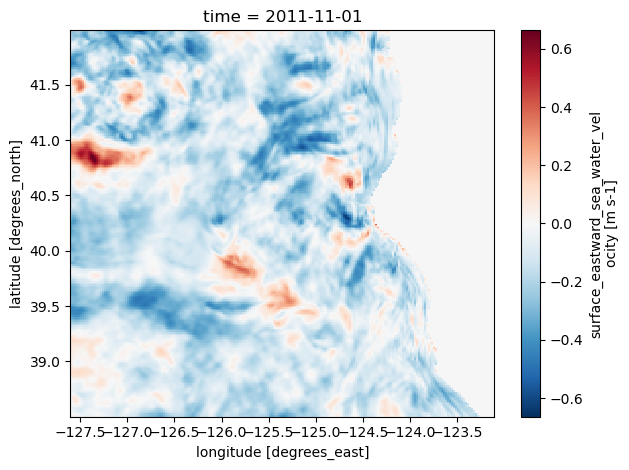

In [20]:
uv_cut['u'].isel(time=0).plot()

In [21]:
uv_model

<xarray.Dataset>
Dimensions:  (time: 9119, i: 237, j: 216, k: 1)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
  * i        (i) int64 656 657 658 659 660 661 662 ... 887 888 889 890 891 892
  * j        (j) int64 211 212 213 214 215 216 217 ... 421 422 423 424 425 426
    lon      (i, j) float32 ...
    lat      (i, j) float32 ...
  * k        (k) int64 0
Data variables: (12/14)
    u        (time, i, j) float32 ...
    DXC      (i, j) float32 ...
    DXG      (i, j) float32 ...
    DXV      (i, j) float32 ...
    DYC      (i, j) float32 ...
    DYG      (i, j) float32 ...
    ...       ...
    RAC      (i, j) float32 ...
    RAZ      (i, j) float32 ...
    XG       (i, j) float32 ...
    YG       (i, j) float32 ...
    hFacC    (i, j, k) float32 ...
    v        (time, i, j) float32 ...

In [69]:
#convert to spatial coordinates
import pyproj
lat_box = np.array(uv_model['lat'][:,:])
print(np.shape(lat_box))

lon_box = np.array(uv_model['lon'][:,:])
print(np.shape(lon_box))
source_crs = 'epsg:3310' # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(target_crs, source_crs)
proj_in_x, proj_in_y = latlon_to_polar.transform(lat_box, lon_box)


(237, 216)
(237, 216)


In [70]:
#print(np.array(uv_model['lon'][0,:]))
X = np.array(proj_in_x[0,:])
Y = np.array(proj_in_y[:,0])

In [71]:
time_cut = uv_cut['time']

spatial_u = xr.DataArray(np.array(uv_cut['u']),coords = [time_cut,Y,X], dims = ['time','Y','X'],name='u')
spatial_v = xr.DataArray(np.array(uv_cut['v']),coords = [time_cut,Y,X], dims = ['time','Y','X'],name='v')


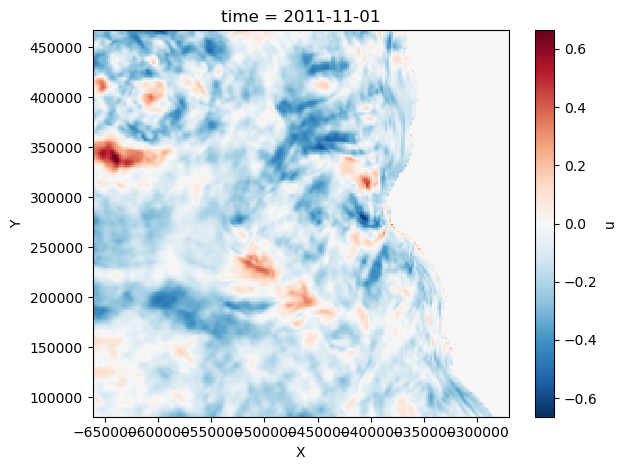

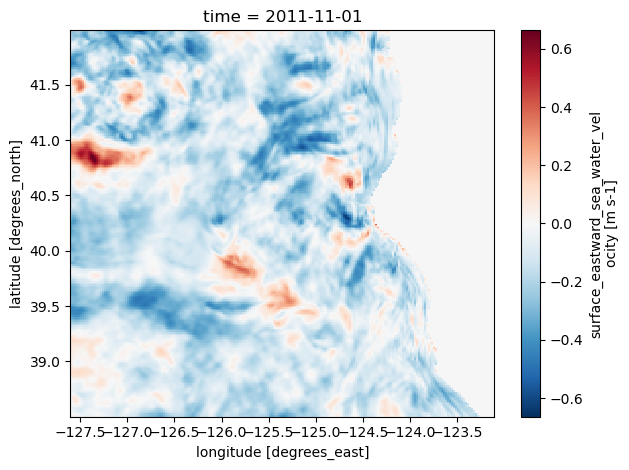

In [72]:
spatial_u.isel(time=0).plot()
plt.show()
uv_cut['u'].isel(time=0).plot()

In [73]:
spatial_u.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/u_spatial_short.nc')
spatial_v.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/v_spatial_short.nc')

In [5]:
test_uv_filepaths = ['/media/basil/Elements/data/Thesis/LLC4320/v_spatial_short.nc','/media/basil/Elements/data/Thesis/LLC4320/u_spatial_short.nc'] 
test_uv = xr.open_mfdataset(test_uv_filepaths)
test_uv['u'].attrs['long_name'] = 'surface_eastward_sea_water_velocity'
test_uv['u'].attrs['units'] = 'm s-1'
test_uv['u'].attrs['standard_name'] = 'surface_eastward_sea_water_velocity'
test_uv['u'].attrs['grid_mapping'] = 'epsg:3310'
test_uv['v'].attrs['long_name'] = 'surface_northward_sea_water_velocity'
test_uv['v'].attrs['units'] = 'm s-1'
test_uv['v'].attrs['standard_name'] = 'surface_northward_sea_water_velocity'
test_uv['v'].attrs['grid_mapping'] = 'epsg:3310'
test_uv['Y'].attrs['long_name'] = 'projection_y_coordinate'
test_uv['Y'].attrs['units'] = 'm'
test_uv['Y'].attrs['standard_name'] = 'projection_y_coordinate'

test_uv['X'].attrs['long_name'] = 'projection_x_coordinate'
test_uv['X'].attrs['units'] = 'm'
test_uv['X'].attrs['standard_name'] = 'projection_x_coordinate'


In [6]:
test_uv['u']

<xarray.DataArray 'u' (time: 120, Y: 237, X: 216)>
dask.array<open_dataset-u, shape=(120, 237, 216), dtype=float32, chunksize=(120, 237, 216), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2011-11-05T23:00:00
  * Y        (Y) float64 8.117e+04 8.284e+04 8.451e+04 ... 4.643e+05 4.659e+05
  * X        (X) float64 -6.607e+05 -6.589e+05 ... -2.731e+05 -2.712e+05
Attributes:
    long_name:      surface_eastward_sea_water_velocity
    units:          m s-1
    standard_name:  surface_eastward_sea_water_velocity
    grid_mapping:   epsg:3310

In [87]:
mean_diff = test_uv['X'].diff(dim='X').mean()#.isel(time=0).plot()
print(test_uv['Y'])#.diff(dim='X').mean()#.isel(time=0).plot()

time_cut = uv_cut['time']
X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
spatial_u = xr.DataArray(np.array(uv_cut['u']),coords = [time_cut,Y_uniform,X_uniform], dims = ['time','Y','X'],name='u')
spatial_v = xr.DataArray(np.array(uv_cut['v']),coords = [time_cut,Y_uniform,X_uniform], dims = ['time','Y','X'],name='v')


<xarray.DataArray 'Y' (Y: 237)>
array([ 81172.038532,  82842.476424,  84512.48653 , ..., 462735.291461,
       464324.545528, 465913.346397])
Coordinates:
  * Y        (Y) float64 8.117e+04 8.284e+04 8.451e+04 ... 4.643e+05 4.659e+05
Attributes:
    long_name:      projection_y_coordinate
    units:          m
    standard_name:  projection_y_coordinate


In [88]:
spatial_u.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/u_spatial_short_uniform.nc')
spatial_v.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/v_spatial_short_uniform.nc')



In [7]:
test_uv_filepaths = ['/media/basil/Elements/data/Thesis/LLC4320/v_spatial_short_uniform.nc','/media/basil/Elements/data/Thesis/LLC4320/u_spatial_short_uniform.nc'] 
test_uv = xr.open_mfdataset(test_uv_filepaths)
test_uv = xr.open_mfdataset(test_uv_filepaths)
test_uv['u'].attrs['long_name'] = 'x_sea_water_velocity'
test_uv['u'].attrs['units'] = 'm s-1'
test_uv['u'].attrs['standard_name'] = 'x_sea_water_velocity'
test_uv['u'].attrs['grid_mapping'] = 'epsg:3310'
test_uv['v'].attrs['long_name'] = 'y_sea_water_velocity'
test_uv['v'].attrs['units'] = 'm s-1'
test_uv['v'].attrs['standard_name'] = 'y_sea_water_velocity'
test_uv['v'].attrs['grid_mapping'] = 'epsg:3310'
test_uv['Y'].attrs['long_name'] = 'projection_y_coordinate'
test_uv['Y'].attrs['units'] = 'm'
test_uv['Y'].attrs['standard_name'] = 'projection_y_coordinate'


test_uv['X'].attrs['long_name'] = 'projection_x_coordinate'
test_uv['X'].attrs['units'] = 'm'
test_uv['X'].attrs['standard_name'] = 'projection_x_coordinate'
proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs  <>'

In [8]:
test_uv
projection = xr.Dataset(data_vars = dict(projection=1),attrs=dict(earth_radius=6371000.0,proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs',)) 
#test_uv_proj = xr.merge(test_uv,projection['projection'])
projection['projection'].attrs = projection.attrs
test_uv_proj = xr.merge([test_uv,projection])

In [9]:

o = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o_diffusion = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o.set_config('general:coastline_action', 'stranding') 
o.set_config('drift:advection_scheme', 'runge-kutta4')
o.set_config('general:time_step_minutes', 60)
o.set_config('drift:stokes_drift', False)
o_diffusion.set_config('general:coastline_action', 'stranding') 
o_diffusion.set_config('drift:advection_scheme', 'runge-kutta4')
o_diffusion.set_config('general:time_step_minutes', 60)
o_diffusion.set_config('drift:stokes_drift', False)
o_diffusion.set_config('drift:current_uncertainty_uniform', .5)
reader_data = reader_netCDF_CF_generic.Reader(test_uv_proj)
reader_landmask = reader_global_landmask.Reader()
o.add_reader([reader_data,reader_landmask])
o_diffusion.add_reader([reader_data,reader_landmask])

In [14]:
lcs = o.calculate_ftle(
    time=reader_data.start_time + timedelta(hours=1),
    time_step=timedelta(minutes=60),
    duration=timedelta(hours=6), delta=1000,
    RLCS=False)


14:22:00 DEBUG   opendrift.config:161: Adding 15 config items from __init__
14:22:00 DEBUG   opendrift.config:171:   Overwriting config item readers:max_number_of_fails
14:22:00 DEBUG   opendrift.config:161: Adding 5 config items from __init__
14:22:00 INFO    opendrift.models.basemodel:528: OpenDriftSimulation initialised (version 1.11.0)
14:22:00 DEBUG   opendrift.config:161: Adding 15 config items from oceandrift
14:22:00 DEBUG   opendrift.config:171:   Overwriting config item seed:z
14:22:00 DEBUG   opendrift.readers.basereader.variables:593: Setting buffer size 4 for reader <xarray.Dataset>
Dimensions:     (time: 120, Y: 237, X: 216)
Coordinates:
  * time        (time) datetime64[ns] 2011-11-01 ... 2011-11-05T23:00:00
  * Y           (Y) int64 81172 82796 84420 86044 ... 461188 462812 464436
  * X           (X) int64 -660722 -658918 -657114 ... -276470 -274666 -272862
Data variables:
    u           (time, Y, X) float32 dask.array<chunksize=(120, 237, 216), meta=np.ndarray>
    v 

In [15]:
#uv_model['lat'][][]
o.plot(lcs=lcs, vmin=1e-7, vmax=1e-4, colorbar=True,show_elements=False)

14:22:41 DEBUG   opendrift.models.basemodel:2314: Setting up map: corners=None, fast=False, lscale=None


AttributeError: 'OceanDrift' object has no attribute 'elements_scheduled'

In [21]:
lcs_lat = lcs['lat']
lcs_lon = lcs['lon']
lcs_time = lcs['time']
lcs_data = lcs['ALCS'].data


In [47]:
lcs

{'time': [datetime.datetime(2011, 11, 1, 1, 0)],
 'lon': array([[-127.5937393 , -127.58229519, -127.57085085, ..., -123.17450557,
         -123.1630007 , -123.15149574],
        [-127.59465799, -127.5832125 , -127.5717668 , ..., -123.17489099,
         -123.16338472, -123.15187836],
        [-127.5955769 , -127.58413004, -127.57268296, ..., -123.17527649,
         -123.16376883, -123.15226107],
        ...,
        [-127.96058698, -127.94859509, -127.93660294, ..., -123.32844633,
         -123.31638445, -123.30432246],
        [-127.96159637, -127.94960297, -127.93760931, ..., -123.32887002,
         -123.3168066 , -123.30474307],
        [-127.96260601, -127.95061111, -127.93861594, ..., -123.32929381,
         -123.31722886, -123.3051638 ]]),
 'lat': array([[38.50840792, 38.50912715, 38.5098453 , ..., 38.70504868,
         38.70534931, 38.70564885],
        [38.51737512, 38.51809444, 38.51881268, ..., 38.7140401 ,
         38.71434076, 38.71464034],
        [38.52634234, 38.52706175,

In [32]:
time = lcs_time
lat = lcs_lat[:,0]
lon = lcs_lon[0,:]
len(lat)

384

In [33]:
LCS = xr.DataArray(lcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='LCS')

ValueError: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>

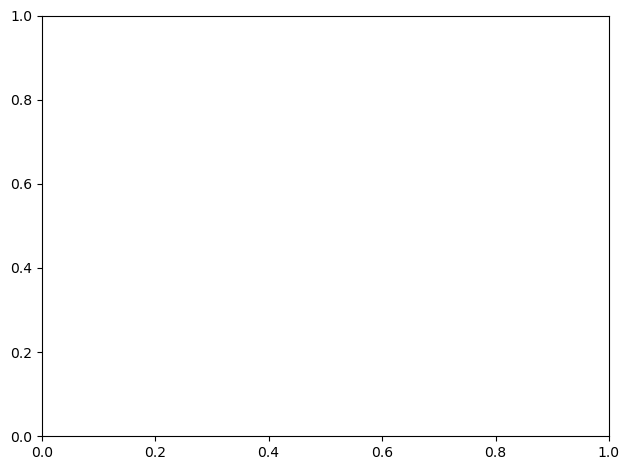

In [57]:
LCS.plot(vmin=1e-7, vmax=1e-4,transform=ccrs.PlateCarree())


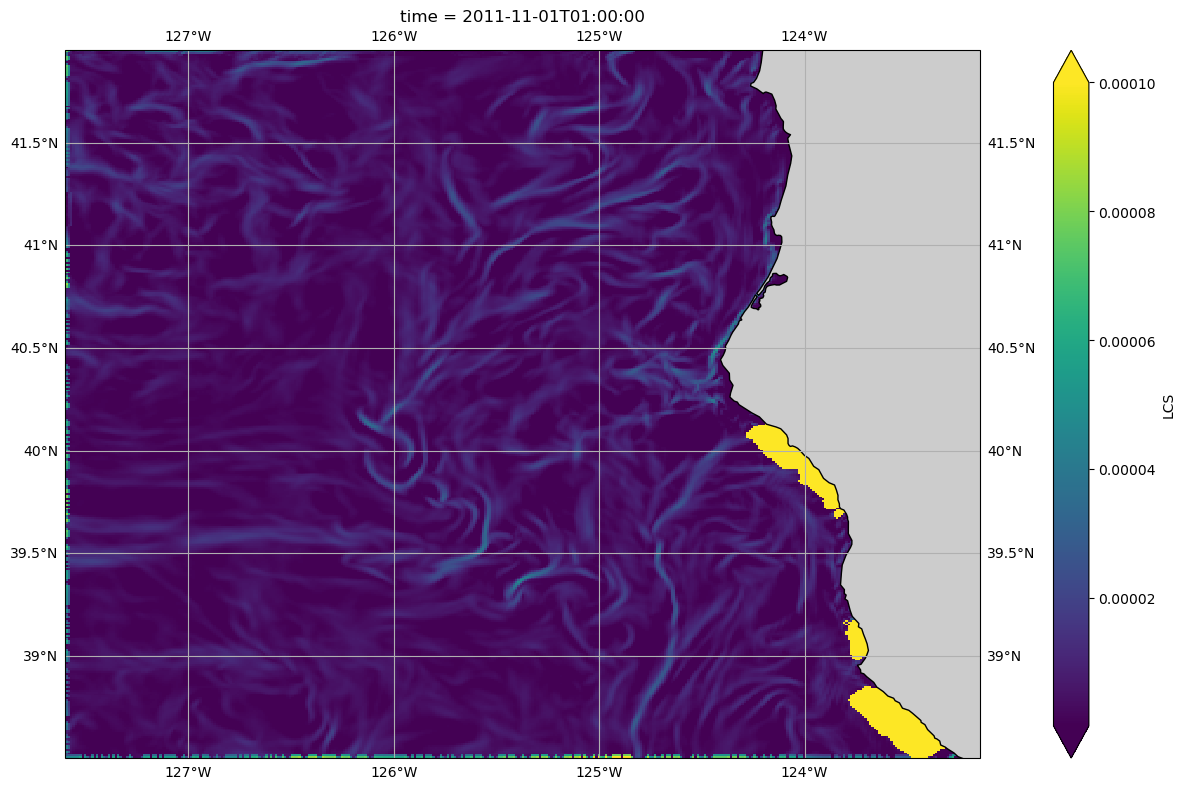

In [59]:
proj = ccrs.ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=proj)
LCS.plot(vmin=1e-7, vmax=1e-4,transform=ccrs.PlateCarree())

coast_10m = cfeature.NaturalEarthFeature("physical", "land", "10m", edgecolor="k", facecolor="0.8")

ax.add_feature(coast_10m)
gl = ax.gridlines(draw_labels=True)
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

In [11]:
start_time = reader_data.start_time
from datetime import timedelta
#o.seed_cone(lon=uv_cut.lon, lat=uv_cut.lat, number=100, time=time)
#o.seed_elements(lon=-124.5249, lat=39.2598, number=5000, radius=1000, time=start_time)
#o.seed_elements(lon=lon_line[], lat=lat_line, number=len(lat_line), radius=1000, time=start_time)

In [10]:
#o.run(duration=timedelta(hours=6), time_step=timedelta(minutes=30))

In [12]:
#o.plot(fast=True)


In [13]:
# from datetime import timedelta
# lcs = o.calculate_ftle(
#     time=reader_data.start_time + timedelta(hours=1),
#     time_step=timedelta(minutes=60),
#     duration=timedelta(hours=6), delta=1000,
#     RLCS=False)

14:16:01 DEBUG   opendrift.models.basemodel:2314: Setting up map: corners=None, fast=False, lscale=None
14:16:01 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: h, extent: (-125.0051330566406, -124.08085021972656, 38.96339874267578, 39.48945922851562)..
14:16:10 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: h, extent: (-125.0051330566406, -124.08085021972656, 38.96339874267578, 39.48945922851562)..
14:16:12 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: h, extent: (-125.0051330566406, -124.08085021972656, 38.96339874267578, 39.48945922851562)..


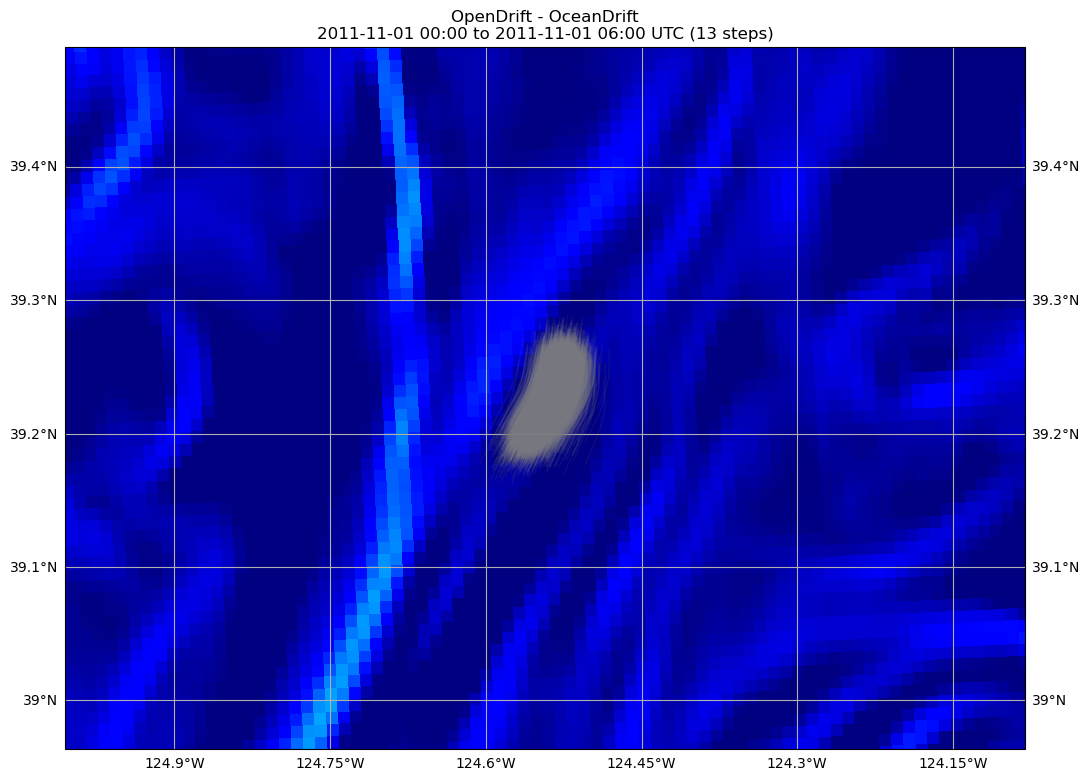

(<GeoAxes: title={'center': 'OpenDrift - OceanDrift\n2011-11-01 00:00 to 2011-11-01 06:00 UTC (13 steps)'}>,
 <Figure size 1100x808.195 with 1 Axes>)

In [139]:
o.plot(lcs=lcs, vmin=1e-7, vmax=1e-4, colorbar=True,show_elements=False)

In [138]:
lcs

{'time': [datetime.datetime(2011, 11, 1, 1, 0)],
 'lon': array([[-127.5937393 , -127.58229519, -127.57085085, ..., -123.17450557,
         -123.1630007 , -123.15149574],
        [-127.59465799, -127.5832125 , -127.5717668 , ..., -123.17489099,
         -123.16338472, -123.15187836],
        [-127.5955769 , -127.58413004, -127.57268296, ..., -123.17527649,
         -123.16376883, -123.15226107],
        ...,
        [-127.96058698, -127.94859509, -127.93660294, ..., -123.32844633,
         -123.31638445, -123.30432246],
        [-127.96159637, -127.94960297, -127.93760931, ..., -123.32887002,
         -123.3168066 , -123.30474307],
        [-127.96260601, -127.95061111, -127.93861594, ..., -123.32929381,
         -123.31722886, -123.3051638 ]]),
 'lat': array([[38.50840792, 38.50912715, 38.5098453 , ..., 38.70504868,
         38.70534931, 38.70564885],
        [38.51737512, 38.51809444, 38.51881268, ..., 38.7140401 ,
         38.71434076, 38.71464034],
        [38.52634234, 38.52706175,

In [63]:
o = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o_diffusion = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o.set_config('general:coastline_action', 'stranding') 
o.set_config('drift:advection_scheme', 'runge-kutta4')
o.set_config('general:time_step_minutes', 60)
o.set_config('drift:stokes_drift', False)
o_diffusion.set_config('general:coastline_action', 'stranding') 
o_diffusion.set_config('drift:advection_scheme', 'runge-kutta4')
o_diffusion.set_config('general:time_step_minutes', 60)
o_diffusion.set_config('drift:stokes_drift', False)
o_diffusion.set_config('drift:current_uncertainty_uniform', .5)

21:22:04 DEBUG   opendrift.models.oceandrift:116: No machine learning correction available.
21:22:04 DEBUG   opendrift.config:161: Adding 48 config items from environment
21:22:04 DEBUG   opendrift.config:161: Adding 5 config items from environment


In [97]:

reader_norkyst = reader_netCDF_CF_generic.Reader('/home/basil/Desktop/opendrift/tests/test_data/16Nov2015_NorKyst_z_surface/norkyst800_subset_16Nov2015.nc')
o.add_reader([reader_norkyst])
# lcs = o.calculate_ftle(
#     time=reader_norkyst.start_time + timedelta(hours=20),
#     time_step=timedelta(minutes=30),
#     duration=timedelta(hours=5), delta=1000,
#     RLCS=False)

In [98]:
reader_norkyst

Reader: /home/basil/Desktop/opendrift/tests/test_data/16Nov2015_NorKyst_z_surface/norkyst800_subset_16Nov2015.nc
Projection: 
  +proj=stere +lat_0=90 +lon_0=70 +k=0.933012701892219 +x_0=0 +y_0=0 +R=6371000 +units=m +no_defs +type=crs
Coverage: [degrees]
  xmin: -2952800.000000   xmax: -2712800.000000   step: 800   numx: 301
  ymin: -1384000.000000   ymax: -1224000.000000   step: 800   numy: 201
  Corners (lon, lat):
    (  2.52,  59.90)  (  4.28,  61.89)
    (  5.11,  59.32)  (  7.03,  61.26)
Vertical levels [m]: 
  [-0.]
Available time range:
  start: 2015-11-16 00:00:00   end: 2015-11-18 18:00:00   step: 1:00:00
    67 times (0 missing)
Variables:
  x_sea_water_velocity
  y_sea_water_velocity
  sea_water_speed - derived from ['x_sea_water_velocity', 'y_sea_water_velocity']

21:40:06 DEBUG   opendrift.models.basemodel:2314: Setting up map: corners=None, fast=False, lscale=None
21:40:07 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: h, extent: (3.817673778533936, 4.893801593780519, 59.97312240600585, 60.55040283203127)..
21:40:39 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: h, extent: (3.817673778533936, 4.893801593780519, 59.97312240600585, 60.55040283203127)..
21:40:41 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: h, extent: (3.817673778533936, 4.893801593780519, 59.97312240600585, 60.55040283203127)..


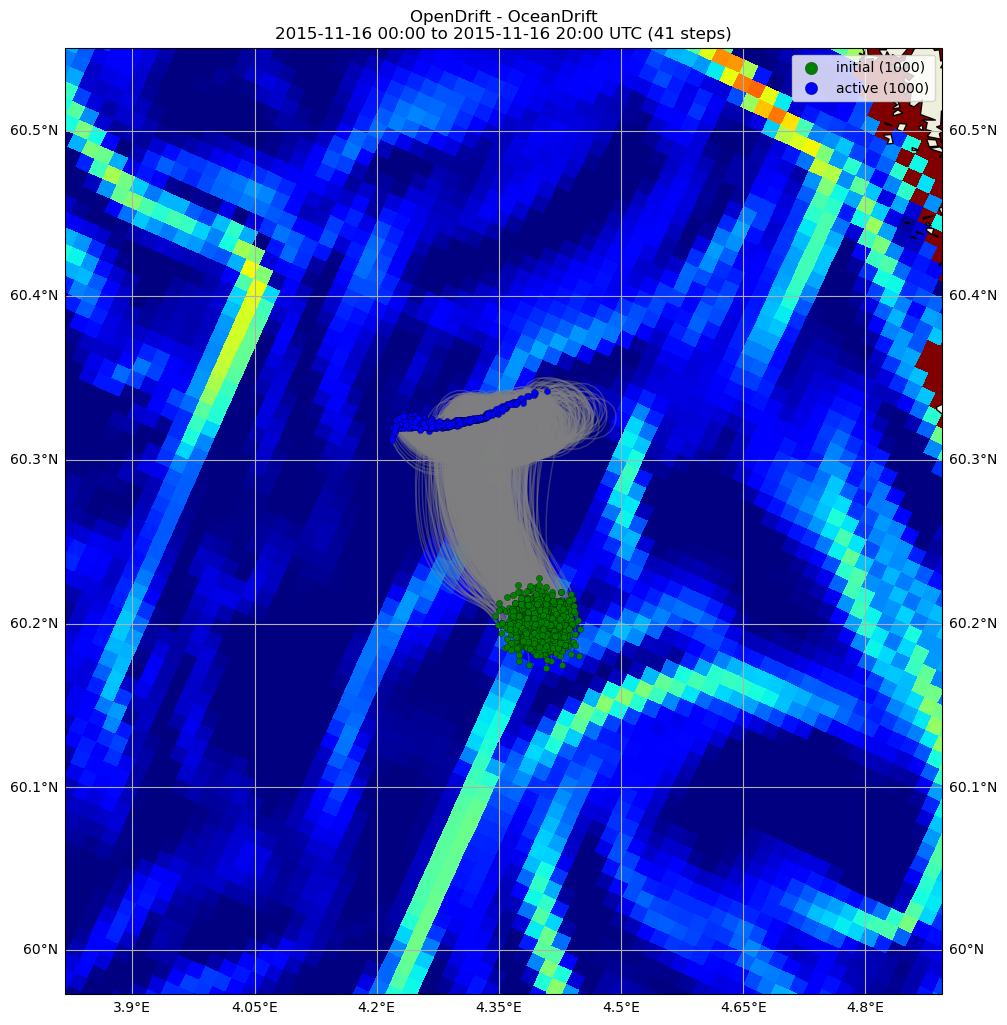

(<GeoAxes: title={'center': 'OpenDrift - OceanDrift\n2015-11-16 00:00 to 2015-11-16 20:00 UTC (41 steps)'}>,
 <Figure size 1017.15x1100 with 1 Axes>)

In [67]:
# o = o.clone()
# o.seed_elements(lon=4.4, lat=60.2, number=1000, radius=1000,
#                 time=reader_norkyst.start_time)
# o.run(end_time=reader_norkyst.start_time+timedelta(hours=20),
#       time_step=timedelta(minutes=30))
o.plot(lcs=lcs, vmin=1e-7, vmax=1e-4, colorbar=True)

In [60]:
data = xr.open_dataset('/home/basil/Desktop/opendrift/tests/test_data/16Nov2015_NorKyst_z_surface/norkyst800_subset_16Nov2015.nc')

In [104]:
data

<xarray.Dataset>
Dimensions:           (X: 301, Y: 201, depth: 1, time: 67)
Coordinates:
  * X                 (X) float64 -2.953e+06 -2.952e+06 ... -2.713e+06
  * Y                 (Y) float64 -1.384e+06 -1.383e+06 ... -1.224e+06
  * depth             (depth) float64 0.0
  * time              (time) datetime64[ns] 2015-11-16 ... 2015-11-18T18:00:00
Data variables:
    projection_stere  int32 -2147483647
    u                 (time, depth, Y, X) float32 ...
    v                 (time, depth, Y, X) float32 ...
Attributes: (12/32)
    file:              /prod/forecast/run/NorKyst-800m/ocean_his.nc
    type:              ROMS/TOMS history file
    title:             ROMS 3.5 - NorKyst-800m
    rst_file:          /prod/forecast/run/NorKyst-800m/ocean_rst.nc
    his_file:          /prod/forecast/run/NorKyst-800m/ocean_his.nc
    avg_file:          /prod/forecast/run/NorKyst-800m/ocean_avg.nc
    ...                ...
    tiling:            032x016
    history:           Mon Nov 16 14:46:04 2015: ncks -O -4 -v u,v,projection...
    ana_file:          ROMS/Functionals/ana_btflux.h, /prod/forecast/sea/ROMS...
    CPP_options:       NORKYST800M, ADD_FSOBC, ADD_M2OBC, ALBEDO, ATM_PRESS, ...
    Conventions:       CF-1.4
    NCO:               4.0.8

In [103]:
np.asarray(data['projection_stere'])

#test_uv['projection_stere'].attrs = data['projection_stere'].attrs

array(-2147483647, dtype=int32)

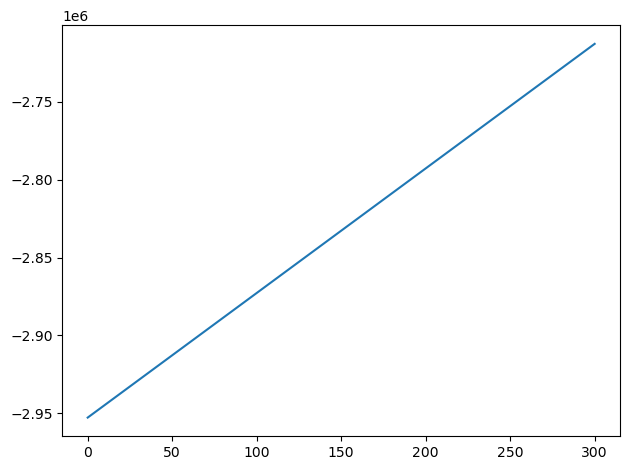

In [91]:
plt.plot(data['X'])
#plt.plot(data['Y'])


In [95]:
import opendrift.models as od_models
od_models.physics_methods.distance_along_trajectory([lon_line[6],lon_line[7]],[lat_line[0],lat_line[0]])
#in order to get FTLE, need to translate into position space X and Y

[1817.3598372647998]

In [83]:
lon_line[1]-lon_line[0]

0.020835876